In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from torchvision import models

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.relu3 = nn.ReLU()
        self.relu4 = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = self.relu3(self.fc1(x))
        x = self.relu4(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)



100%|██████████| 170M/170M [00:06<00:00, 26.7MB/s] 


In [4]:
USE_PRETRAINED_MODEL = True

if USE_PRETRAINED_MODEL:
    print("Using existing trained model")
    net.load_state_dict(torch.load('cifar_torchvision.pt'))
else:
    for epoch in range(5):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs
            inputs, labels = data
            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 2000 == 1999:    # print every 2000 mini-batches
                print('[%d, %5d] loss: %.3f' %
                      (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0

    print('Finished Training')
    torch.save(net.state_dict(), 'models/cifar_torchvision.pt')

Using existing trained model


c:\Repositories\proai\course11-xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


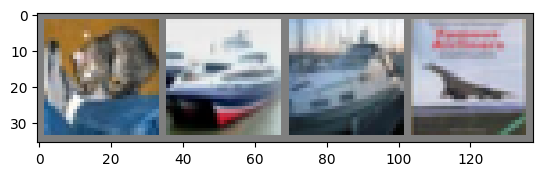

GroundTruth:    cat  ship  ship plane
Predicted:    cat  ship  ship  ship


In [5]:
from captum.attr import IntegratedGradients
from captum.attr import Saliency
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))


outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))



In [53]:
ind = 3
input = images[ind].unsqueeze(0)
input.requires_grad = True
net.eval()

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu1): ReLU()
  (relu2): ReLU()
  (relu3): ReLU()
  (relu4): ReLU()
)

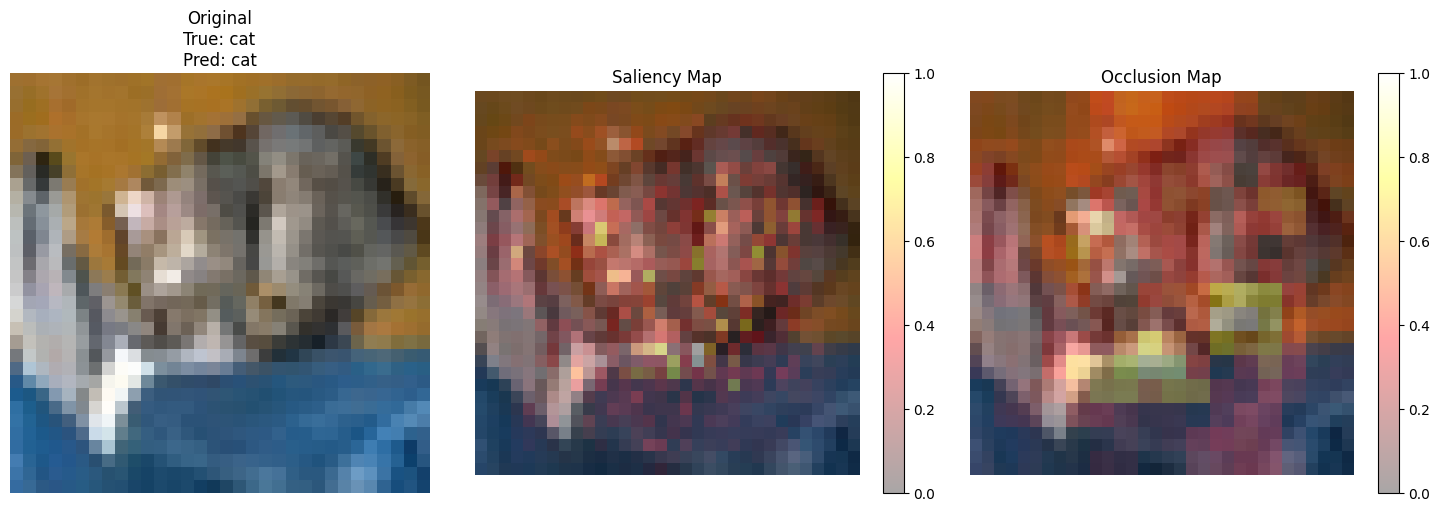

In [55]:
from captum.attr import Saliency, Occlusion
import torch.nn.functional as F

# Prepariamo l'immagine
dataiter = iter(testloader)
images, labels = next(dataiter)
input_img = images[0].unsqueeze(0)
input_label = labels[0]

# 1. Saliency Map
saliency = Saliency(net)
saliency_attr = saliency.attribute(input_img, target=input_label)

# 2. Occlusion
occlusion = Occlusion(net)
occlusion_attr = occlusion.attribute(
    input_img,
    target=input_label,
    strides=(3, 2, 2),
    sliding_window_shapes=(3, 4, 4),
    baselines=0
)

# Visualizzazione
plt.figure(figsize=(15, 5))

# 1. Immagine originale
plt.subplot(131)
orig_img = input_img.squeeze().cpu().detach().numpy()
orig_img = np.transpose(orig_img, (1, 2, 0))  # Convertiamo da CxHxW a HxWxC
plt.imshow(orig_img * 0.5 + 0.5)  # Denormalizziamo
plt.title(f'Original\nTrue: {classes[labels[0]]}\nPred: {classes[predicted[0]]}')
plt.axis('off')

# 2. Saliency Map sovrapposta
plt.subplot(132)
saliency_map = saliency_attr.abs().sum(dim=1).squeeze().cpu().detach().numpy()
# Normalizziamo la saliency map
saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min())

plt.imshow(orig_img * 0.5 + 0.5)
plt.imshow(saliency_map, cmap='hot', alpha=0.35)
plt.title('Saliency Map')
plt.colorbar()
plt.axis('off')

# 3. Occlusion Map sovrapposta
plt.subplot(133)
occlusion_map = occlusion_attr.abs().sum(dim=1).squeeze().cpu().detach().numpy()
# Normalizziamo la occlusion map
occlusion_map = (occlusion_map - occlusion_map.min()) / (occlusion_map.max() - occlusion_map.min())

plt.imshow(orig_img * 0.5 + 0.5)
plt.imshow(occlusion_map, cmap='hot', alpha=0.35)
plt.title('Occlusion Map')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()